# Digital Green -  Crop Yield Estimation Challenge

Smallholder farmers are crucial contributors to global food production, and in India often suffer most from poverty and malnutrition. These farmers face challenges such as limited access to modern agriculture, unpredictable weather, and resource constraints. To tackle this issue, Digital Green collected data via surveys, offering insights into farming practices, environmental conditions, and crop yields.

The objective of this challenge is to create a machine learning solution to predict the crop yield per acre of rice or wheat crops in India. Our goal is to empower these farmers and break the cycle of poverty and malnutrition.

A crop yield model could revolutionise Indian agriculture, and serve as a global model for smallholder farmers. Accurate yield predictions empower smallholder farmers to make informed planting and resource allocation decisions, reducing poverty and malnutrition and improving food security. As climate change intensifies, adaptive farming practices become crucial, making precise yield predictions even more valuable. Solutions developed here can drive sustainable agriculture and ensure a stable food supply for the world's growing population. This challenge offers data scientists and machine learning enthusiasts a unique chance to make a real difference in vulnerable populations' lives while advancing global food security in a concise, impactful way.

***Copied from Zindi Challenge***

GOALS

- predict crop yield per acre
- make informed planting and resource allocation decisions

## Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno
import seaborn as sns

In [2]:
#Load the dataset
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
var_desc = pd.read_csv('VariableDescription.csv')
submission = pd.read_csv('SampleSubmission.csv')

### Data Cleaning & EDA

In [3]:
train_data.head()

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,2022-07-20,5,Manual_PuddledRandom,2022-06-27,...,machine,2022-11-16,NaN,2022-11-16,machine,30,40,plowed_in_soil,0.312500,600
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-18,5,Manual_PuddledRandom,2022-06-20,...,hand,2022-11-25,3.0,2022-12-24,machine,24,10,plowed_in_soil,0.312500,600
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,2022-06-30,6,Manual_PuddledRandom,2022-06-20,...,hand,2022-12-12,480.0,2023-01-11,machine,30,10,plowed_in_soil,0.148148,225
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,2022-06-16,6,Manual_PuddledRandom,2022-06-17,...,hand,2022-12-02,240.0,2022-12-29,hand,26,10,plowed_in_soil,0.222222,468
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,2022-07-19,4,Manual_PuddledRandom,2022-06-21,...,machine,2022-11-30,NaN,2022-12-02,machine,24,40,plowed_in_soil,0.468750,550


In [4]:
print(train_data["Yield"].describe())

count     3870.000000
mean       594.269251
std        651.916953
min          4.000000
25%        300.000000
50%        425.000000
75%        740.000000
max      16800.000000
Name: Yield, dtype: float64


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3870 entries, 0 to 3869
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  3870 non-null   object 
 1   District                            3870 non-null   object 
 2   Block                               3870 non-null   object 
 3   CultLand                            3870 non-null   int64  
 4   CropCultLand                        3870 non-null   int64  
 5   LandPreparationMethod               3870 non-null   object 
 6   CropTillageDate                     3870 non-null   object 
 7   CropTillageDepth                    3870 non-null   int64  
 8   CropEstMethod                       3870 non-null   object 
 9   RcNursEstDate                       3787 non-null   object 
 10  SeedingSowingTransplanting          3870 non-null   object 
 11  SeedlingsPerPit                     3581 no

In [6]:
train_data.describe()

,CultLand,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,...,BasalUrea,1tdUrea,1appDaysUrea,2tdUrea,2appDaysUrea,Harv_hand_rent,Residue_length,Residue_perc,Acre,Yield
count,3870.000000,3870.000000,3870.000000,3581.000000,3677.000000,2988.000000,3632.000000,1453.000000,1196.000000,3870.000000,...,2166.000000,3314.000000,3314.000000,1176.000000,1170.000000,3618.000000,3870.000000,3870.000000,3870.000000,3870.000000
mean,28.527907,24.727132,4.488372,2.706507,8.017677,379.726908,3.247522,29.731590,57.445652,2.184496,...,13.351801,11.513881,29.200362,7.375000,58.764957,536.622443,26.517829,11.767442,0.292826,594.269251
std,30.454218,27.994802,1.133044,7.624397,42.612470,419.724782,2.207276,122.680882,328.251615,0.634632,...,9.701597,8.715856,12.139109,5.932502,11.356588,1138.613827,3.192873,7.064864,0.206918,651.916953
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,10.000000,0.045455,4.000000
25%,12.000000,10.000000,4.000000,2.000000,2.000000,150.000000,2.000000,1.000000,1.000000,2.000000,...,7.000000,6.000000,23.000000,4.000000,58.000000,150.000000,25.000000,10.000000,0.156250,300.000000
50%,20.000000,20.000000,4.000000,2.000000,4.000000,250.000000,3.000000,3.000000,2.000000,2.000000,...,10.000000,10.000000,28.000000,6.000000,60.000000,400.000000,26.000000,10.000000,0.227273,425.000000
75%,35.000000,30.000000,5.000000,3.000000,6.000000,450.000000,4.000000,4.000000,5.000000,3.000000,...,16.000000,15.000000,36.000000,10.000000,65.000000,700.000000,30.000000,10.000000,0.370370,740.000000
max,800.000000,800.000000,8.000000,442.000000,2000.000000,6000.000000,15.000000,1400.000000,4000.000000,4.000000,...,90.000000,90.000000,332.000000,67.000000,97.000000,60000.000000,30.000000,40.000000,2.187500,16800.000000


Drop ID and Post Harvest columns.

The goal is predict crop yield and help farmers make better planting decisions. That is my rationale for deleting Haverst columns. 

In [7]:
# drop columns that would not be needed
# we  may have to delete features that would not influence yields like post_harvet variables.

train_data = train_data.drop(columns=["ID"])

post_harvet variables.

- Harv_method
- Harv_date
- Harv_hand_rent
- Threshing_date
- Threshing_method
- Residue_length
- Residue_perc
- Stubble_use
- CropTilageDate: we don't need this


In [8]:
# Drop Post harvest features.

train_data = train_data.drop(columns=[
    "Harv_method",
    "Harv_date",
    "Harv_hand_rent",
    "Threshing_date",
    "Threshing_method",
    "Residue_length",
    "Residue_perc",
    "Stubble_use",
    "CropTillageDate"
])

Distribution of features

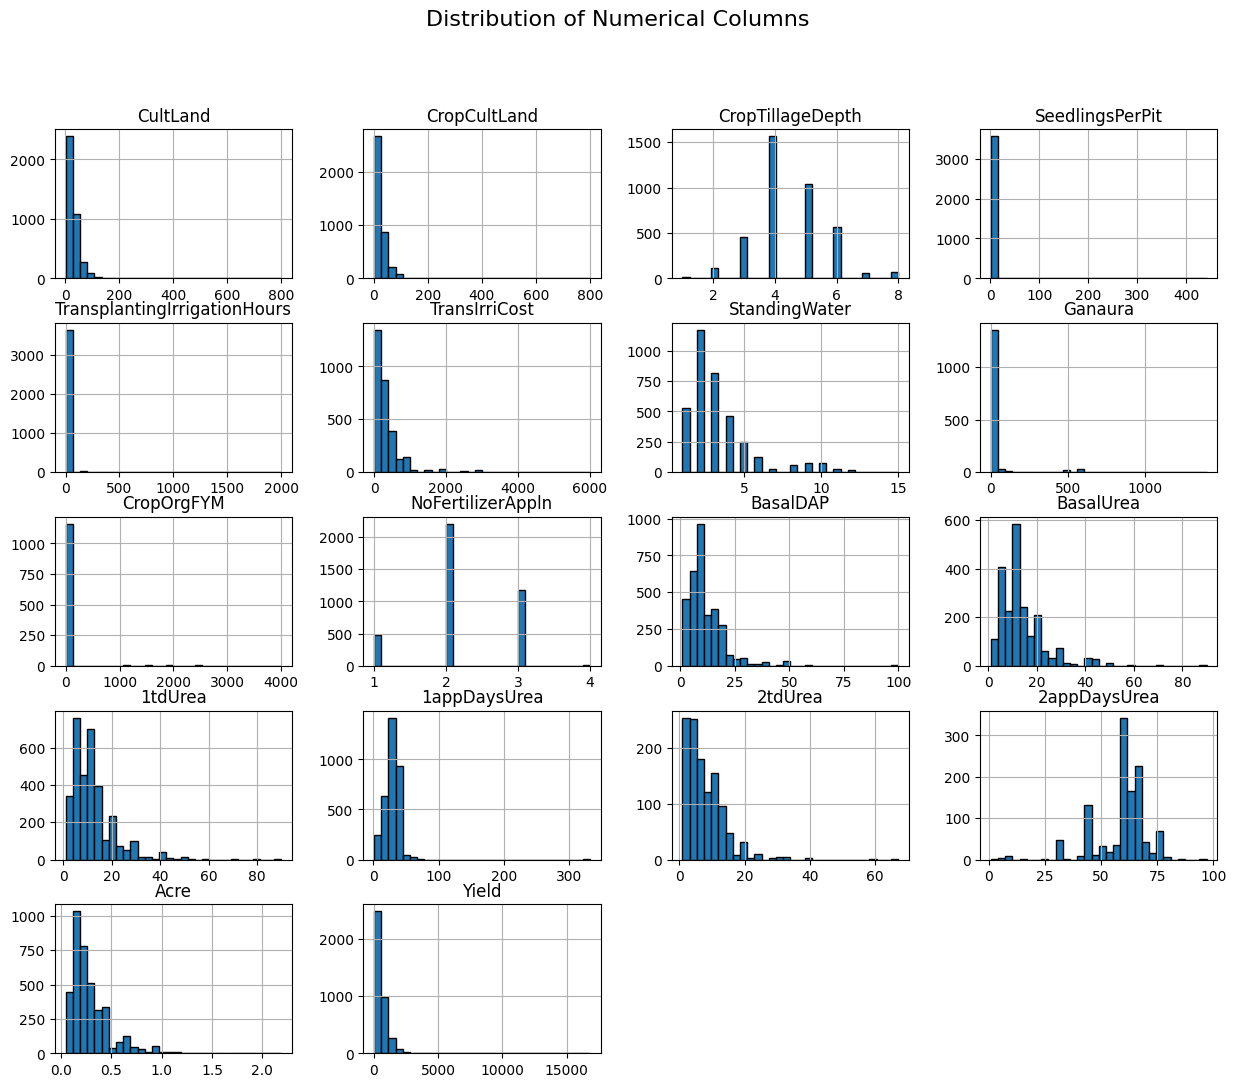

In [9]:
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
train_data[num_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.show()

In [ ]:
print(train_data["Acre"].describe())
# mean value is 0.2928

count    3870.000000
mean        0.292826
std         0.206918
min         0.045455
25%         0.156250
50%         0.227273
75%         0.370370
max         2.187500
Name: Acre, dtype: float64


Analyze Yield and it's outliers

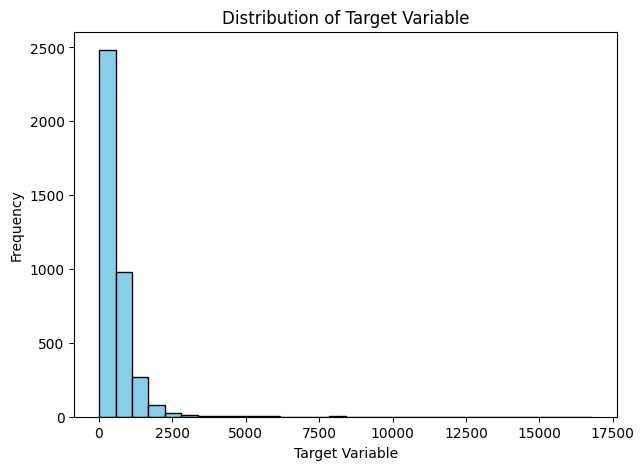

In [11]:
#spread of the target variable

plt.figure(figsize=(7,5))
plt.hist(train_data['Yield'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Target Variable')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.show()

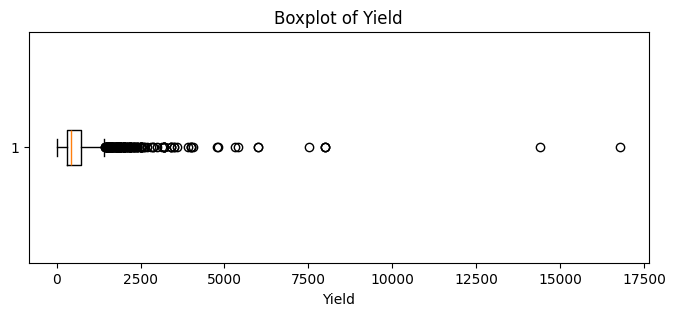

In [12]:
plt.figure(figsize=(8, 3))

plt.boxplot(train_data['Yield'].dropna(), vert=False)

plt.xlabel('Yield')
plt.title('Boxplot of Yield')

plt.show()

In [13]:
filtered_data = train_data[train_data["Yield"] > 6000]

print("Number of records:", len(filtered_data))
print("Average Acre:", filtered_data["Acre"].mean())

Number of records: 6
Average Acre: 0.603219696969697


In [14]:
filtered_data = train_data[train_data["Yield"] < 6000]

print("Number of records:", len(filtered_data))
print("Average Acre:", filtered_data["Acre"].mean())

Number of records: 3862
Average Acre: 0.2923543762325482


Dealing with Yield Outliers

The mean value for the entire Acre column is 0.2928. When yield is < 6000, the Average Acre value is 0.2923.
When Yield is > 6000, average Acre is 0.632. With only 6 rows greater than 6000, it it safe to treat them as
extreme outlier and delete.

In [15]:
train_data = train_data[train_data["Yield"] <= 6000]

Check correlation

Text(0.5, 1.0, 'Correlation Heatmap')

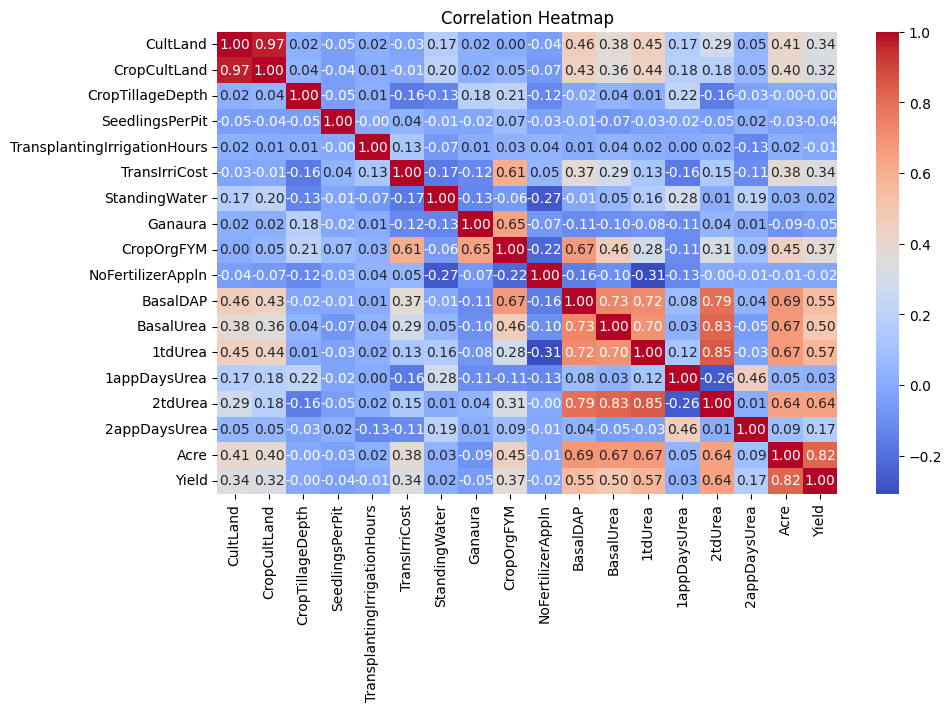

In [16]:
# correlation heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(train_data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

Some features can be consolidated or re-engineered. 

### Analyze Cat variables

In [17]:
cat_cols = train_data.select_dtypes(include=["object"]).columns.tolist()

print(cat_cols)

['District', 'Block', 'LandPreparationMethod', 'CropEstMethod', 'RcNursEstDate', 'SeedingSowingTransplanting', 'NursDetFactor', 'TransDetFactor', 'TransplantingIrrigationSource', 'TransplantingIrrigationPowerSource', 'OrgFertilizers', 'PCropSolidOrgFertAppMethod', 'CropbasalFerts', 'MineralFertAppMethod', 'FirstTopDressFert', 'MineralFertAppMethod.1']


Check relationship between "NursDetFactor" & "TransDetFactor" & RcNursEstDate

In [18]:
train_data[
    train_data["NursDetFactor"].isna()
]["CropEstMethod"].value_counts(normalize=True) * 100

CropEstMethod
LineSowingAfterTillage    71.280277
Broadcasting              28.719723
Name: proportion, dtype: float64

In [19]:
train_data[
    train_data["TransDetFactor"].isna()
]["CropEstMethod"].value_counts(normalize=True) * 100

CropEstMethod
LineSowingAfterTillage    71.280277
Broadcasting              28.719723
Name: proportion, dtype: float64

In [20]:
train_data[
    train_data["RcNursEstDate"].isna()
]["CropEstMethod"].value_counts(normalize=True) * 100

CropEstMethod
Broadcasting    100.0
Name: proportion, dtype: float64

Missingness for "NursDetFactor" & "TransDetFactor" & RcNursEstDate are not Random

Check Irrigation variables

In [21]:
train_data[
    train_data["TransplantingIrrigationSource"].isna()
]["TransplantingIrrigationHours"].value_counts(normalize=True) * 100

Series([], Name: proportion, dtype: float64)

When source is blank, hours is blank as well.

If no irrigation was done, then we don't have a Source or Power source, therefore no Cost associated with Irrigation. We will Impute accordingly below.

## Feature Engineering

Handle dates

In [22]:
train_data["RcNursEstDate"] = pd.to_datetime(
    train_data["RcNursEstDate"],
    errors="coerce"
)

train_data["SeedingSowingTransplanting"] = pd.to_datetime(
    train_data["SeedingSowingTransplanting"],
    errors="coerce"
)


train_data["NurseryStartMonth"] = train_data["RcNursEstDate"].dt.month
train_data['TransplantingMonth'] = train_data['SeedingSowingTransplanting'].dt.month

Drop the date columns

In [23]:
train_data.drop(columns=['RcNursEstDate', 'SeedingSowingTransplanting'],inplace=True)

I want to create a "Yield per Acre" column since that's the goal. I am not sure if I can use it post Model build - still thinking it through.

In [24]:
# create yield-per-acre
# keep Acre & Yield (Do not delete yet)

train_data["Yield_per_Acre"] = train_data["Yield"] / train_data["Acre"]

Urea & Fertilizer Columns:

Fill the null values with ZERO and then we can create new variable

In [25]:
Urea_cols = ["BasalUrea", "1tdUrea", "2tdUrea"]

train_data[Urea_cols] = train_data[Urea_cols].fillna(0)

In [26]:
Fertilizer_cols = ["BasalDAP", "BasalUrea", "1tdUrea", "2tdUrea"]

train_data[Fertilizer_cols] = train_data[Fertilizer_cols].fillna(0)

Strong indication that these variables contain overlapping information. I will vreate new variables:
- Total Urea
- Total Fertilizer

In [27]:
# Strong indication that these variables contain overlapping information.

train_data['TotalUrea'] = (
    train_data['BasalUrea'] +
    train_data['1tdUrea'] +
    train_data['2tdUrea']
)

In [28]:
train_data['TotalFertilizer'] = (
    train_data['BasalDAP'] +
    train_data['BasalUrea'] +
    train_data['1tdUrea'] +
    train_data['2tdUrea']
)

In [29]:
# Drop original

train_data = train_data.drop(
    columns=['BasalUrea', '1tdUrea', '2tdUrea']
)

CultLand vs CropCultLand

In [30]:
# remove CultLand or CropCultLand - both are carrying almost the same information. 
# I believe CropCultLand is specific to the product - keep it. 

train_data = train_data.drop(columns=['CultLand'])

In [31]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3864 entries, 0 to 3869
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   District                            3864 non-null   object 
 1   Block                               3864 non-null   object 
 2   CropCultLand                        3864 non-null   int64  
 3   LandPreparationMethod               3864 non-null   object 
 4   CropTillageDepth                    3864 non-null   int64  
 5   CropEstMethod                       3864 non-null   object 
 6   SeedlingsPerPit                     3575 non-null   float64
 7   NursDetFactor                       3575 non-null   object 
 8   TransDetFactor                      3575 non-null   object 
 9   TransplantingIrrigationHours        3671 non-null   float64
 10  TransplantingIrrigationSource       3749 non-null   object 
 11  TransplantingIrrigationPowerSource  3361 non-nul

Text(0.5, 1.0, 'Correlation Heatmap')

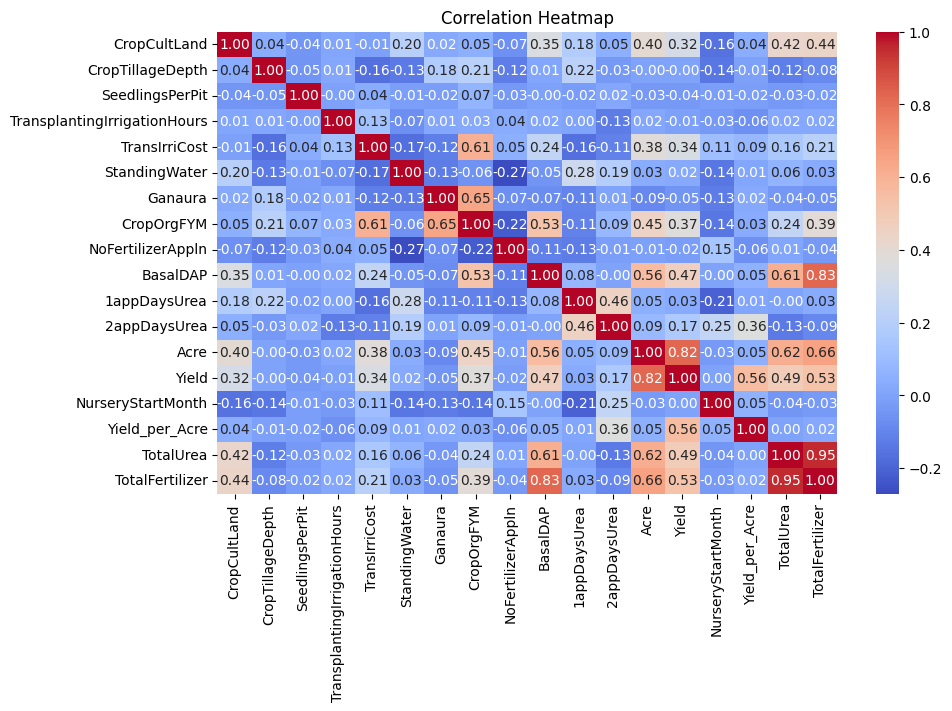

In [32]:
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

# correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

Handle missing values

In [33]:
train_data2 = train_data.copy()

<Axes: >

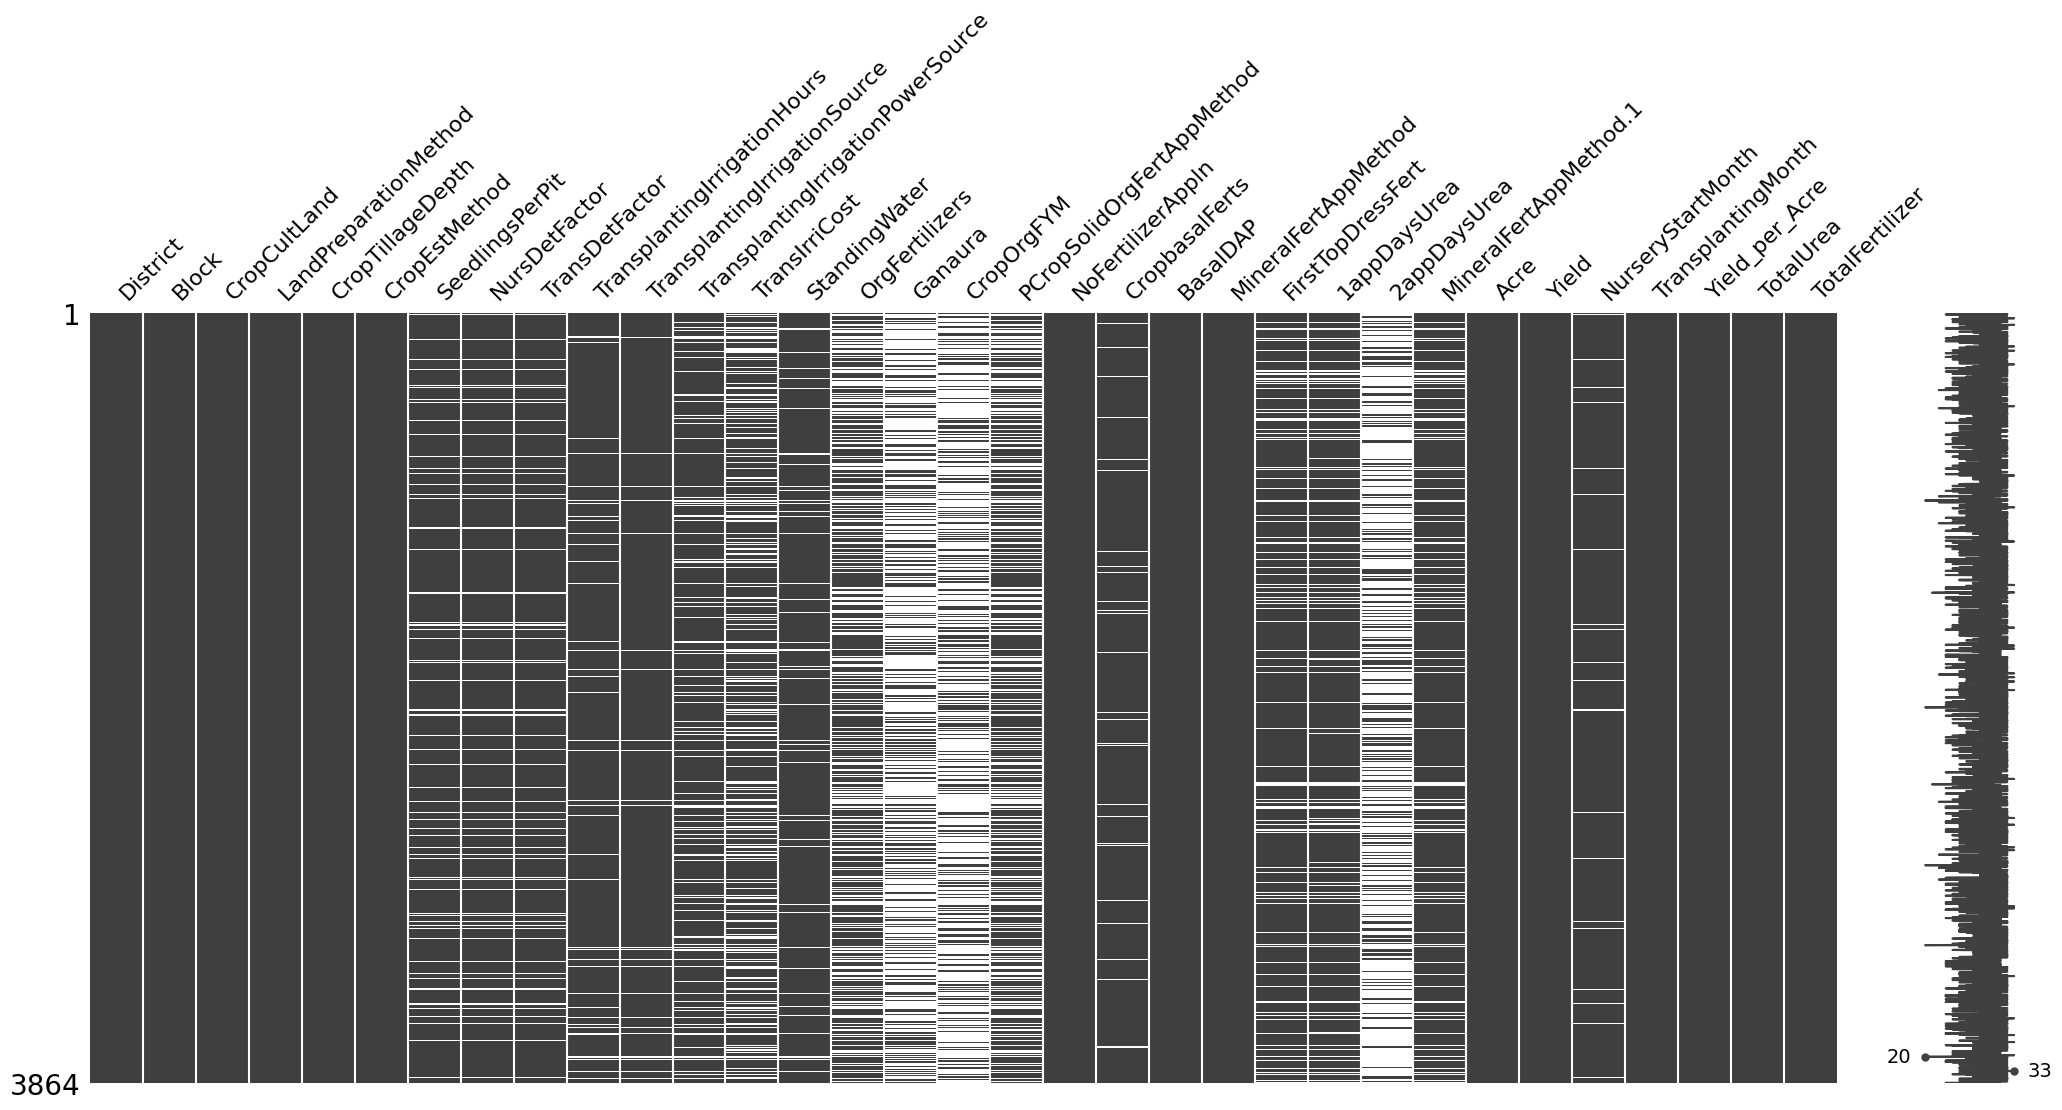

In [34]:
msno.matrix(train_data2)

In [35]:
train_data2['NurseryStartMonth'] = train_data2['NurseryStartMonth'].fillna(0)

In [36]:
#impute irrigation values

train_data2['TransIrriCost'] = train_data2['TransIrriCost'].fillna(0)

train_data2['TransplantingIrrigationPowerSource'] = train_data2['TransplantingIrrigationPowerSource'].fillna(
    'No irrigation'
    )

train_data2['TransplantingIrrigationHours'] = train_data2['TransplantingIrrigationHours'].fillna(0)

train_data2['TransplantingIrrigationSource'] = train_data2['TransplantingIrrigationSource'].fillna(
    'No irrigation'
    )

In [37]:
# other imputations

train_data2['1appDaysUrea'] = train_data2['1appDaysUrea'].fillna(0)
train_data2['SeedlingsPerPit'] = train_data2['SeedlingsPerPit'].fillna(0)

train_data2["StandingWater"] = train_data2["StandingWater"].fillna(
    train_data2["StandingWater"].median()
)

In [38]:
#impute more missing values
train_data2['OrgFertilizers'] = train_data2['OrgFertilizers'].fillna('No organic fertilizer applied')
train_data2['Ganaura'] = train_data2['Ganaura'].fillna(0)
train_data2['CropOrgFYM'] = train_data2['CropOrgFYM'].fillna(0)
train_data2['PCropSolidOrgFertAppMethod'] = train_data2['PCropSolidOrgFertAppMethod'].fillna('No organic fertilizer applied')

In [39]:
missing_counts = train_data2.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

2appDaysUrea              2694
FirstTopDressFert          485
MineralFertAppMethod.1     481
TransDetFactor             289
NursDetFactor              289
CropbasalFerts             188
dtype: int64


In [40]:
# Drop columns we don't need

train_data2 = train_data2.drop(columns=["2appDaysUrea", "FirstTopDressFert", "MineralFertAppMethod.1",
                                      "NursDetFactor", "TransDetFactor", "CropbasalFerts"])

In [41]:
train_data2.isnull().sum()

District                              0
Block                                 0
CropCultLand                          0
LandPreparationMethod                 0
CropTillageDepth                      0
CropEstMethod                         0
SeedlingsPerPit                       0
TransplantingIrrigationHours          0
TransplantingIrrigationSource         0
TransplantingIrrigationPowerSource    0
TransIrriCost                         0
StandingWater                         0
OrgFertilizers                        0
Ganaura                               0
CropOrgFYM                            0
PCropSolidOrgFertAppMethod            0
NoFertilizerAppln                     0
BasalDAP                              0
MineralFertAppMethod                  0
1appDaysUrea                          0
Acre                                  0
Yield                                 0
NurseryStartMonth                     0
TransplantingMonth                    0
Yield_per_Acre                        0


In [42]:
train_data2.head()

,District,Block,CropCultLand,LandPreparationMethod,CropTillageDepth,CropEstMethod,SeedlingsPerPit,TransplantingIrrigationHours,TransplantingIrrigationSource,TransplantingIrrigationPowerSource,...,BasalDAP,MineralFertAppMethod,1appDaysUrea,Acre,Yield,NurseryStartMonth,TransplantingMonth,Yield_per_Acre,TotalUrea,TotalFertilizer
0,Nalanda,Noorsarai,40,TractorPlough FourWheelTracRotavator,5,Manual_PuddledRandom,2.0,5.0,Boring,Electric,...,0.0,Broadcasting,18.0,0.312500,600,6.0,7,1920.000000,35.0,35.0
1,Nalanda,Rajgir,26,WetTillagePuddling TractorPlough FourWheelTrac...,5,Manual_PuddledRandom,2.0,5.0,Boring,Electric,...,15.0,Broadcasting,39.0,0.312500,600,6.0,7,1920.000000,30.0,45.0
2,Gaya,Gurua,10,TractorPlough FourWheelTracRotavator,6,Manual_PuddledRandom,2.0,4.0,Boring,Electric,...,4.0,SoilApplied,65.0,0.148148,225,6.0,8,1518.750000,5.0,9.0
3,Gaya,Gurua,15,TractorPlough FourWheelTracRotavator,6,Manual_PuddledRandom,2.0,0.0,No irrigation,No irrigation,...,6.0,Broadcasting,5.0,0.222222,468,6.0,7,2106.000000,8.0,14.0
4,Nalanda,Noorsarai,60,TractorPlough WetTillagePuddling,4,Manual_PuddledRandom,2.0,9.0,Boring,Electric,...,15.0,Broadcasting,26.0,0.468750,550,6.0,7,1173.333333,60.0,75.0


Categorical columns

In [43]:
cat_cols = train_data2.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in cat_cols:
    print(col)

District
Block
LandPreparationMethod
CropEstMethod
TransplantingIrrigationSource
TransplantingIrrigationPowerSource
OrgFertilizers
PCropSolidOrgFertAppMethod
MineralFertAppMethod


In [44]:
#check unique value count

for col in cat_cols:
    print(f"\n{col}:")
    print(train_data2[col].nunique())


District:
4

Block:
9

LandPreparationMethod:
43

CropEstMethod:
4

TransplantingIrrigationSource:
7

TransplantingIrrigationPowerSource:
4

OrgFertilizers:
32

PCropSolidOrgFertAppMethod:
5

MineralFertAppMethod:
3


low/high cardinality

In [45]:

cat_df=train_data2.select_dtypes(include=[object])
num_df=train_data2.select_dtypes(include=[np.number])

high_cardinality_cols = [col for col in cat_df.columns if cat_df[col].nunique() > 10]
low_cardinality_cols = [col for col in cat_df.columns if cat_df[col].nunique() <= 10]

In [46]:
#encode using one hot encoding for the low cardinality features
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

encoded=ohe.fit_transform(cat_df[low_cardinality_cols].astype(str))
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(low_cardinality_cols))
encoded_df.head()

,District_Gaya,District_Jamui,District_Nalanda,District_Vaishali,Block_Chehrakala,Block_Garoul,Block_Gurua,Block_Jamui,Block_Khaira,Block_Mahua,...,TransplantingIrrigationPowerSource_No irrigation,TransplantingIrrigationPowerSource_Solar,PCropSolidOrgFertAppMethod_Broadcasting,PCropSolidOrgFertAppMethod_No organic fertilizer applied,PCropSolidOrgFertAppMethod_RootApplication,PCropSolidOrgFertAppMethod_SoilApplied,PCropSolidOrgFertAppMethod_Spray,MineralFertAppMethod_Broadcasting,MineralFertAppMethod_RootApplication,MineralFertAppMethod_SoilApplied
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [47]:
encoded_df=encoded_df.reset_index(drop=True)
num_df=num_df.reset_index(drop=True)
target_df=pd.DataFrame(cat_df[high_cardinality_cols])
target_df=target_df.reset_index(drop=True)
df2=pd.concat([num_df, encoded_df, target_df], axis=1)
df2.head()


,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,BasalDAP,...,PCropSolidOrgFertAppMethod_Broadcasting,PCropSolidOrgFertAppMethod_No organic fertilizer applied,PCropSolidOrgFertAppMethod_RootApplication,PCropSolidOrgFertAppMethod_SoilApplied,PCropSolidOrgFertAppMethod_Spray,MineralFertAppMethod_Broadcasting,MineralFertAppMethod_RootApplication,MineralFertAppMethod_SoilApplied,LandPreparationMethod,OrgFertilizers
0,40,5,2.0,5.0,200.0,2.0,0.0,0.0,2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,TractorPlough FourWheelTracRotavator,No organic fertilizer applied
1,26,5,2.0,5.0,125.0,3.0,0.0,0.0,2,15.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,WetTillagePuddling TractorPlough FourWheelTrac...,No organic fertilizer applied
2,10,6,2.0,4.0,80.0,2.0,1.0,1.0,2,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,TractorPlough FourWheelTracRotavator,Ganaura FYM
3,15,6,2.0,0.0,0.0,3.0,1.0,0.0,2,6.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,TractorPlough FourWheelTracRotavator,Ganaura
4,60,4,2.0,9.0,300.0,2.0,0.0,0.0,2,15.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,TractorPlough WetTillagePuddling,No organic fertilizer applied


I will drop Yield per Acre - 

In [48]:
train_data2 = train_data2.drop(columns=["Yield_per_Acre"])

Split Data

In [49]:
X = df2.drop(['Yield'], axis=1)
y = df2['Yield']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(3091, 55) (773, 55) (3091,) (773,)


In [51]:
df2.head()

,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,BasalDAP,...,PCropSolidOrgFertAppMethod_Broadcasting,PCropSolidOrgFertAppMethod_No organic fertilizer applied,PCropSolidOrgFertAppMethod_RootApplication,PCropSolidOrgFertAppMethod_SoilApplied,PCropSolidOrgFertAppMethod_Spray,MineralFertAppMethod_Broadcasting,MineralFertAppMethod_RootApplication,MineralFertAppMethod_SoilApplied,LandPreparationMethod,OrgFertilizers
0,40,5,2.0,5.0,200.0,2.0,0.0,0.0,2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,TractorPlough FourWheelTracRotavator,No organic fertilizer applied
1,26,5,2.0,5.0,125.0,3.0,0.0,0.0,2,15.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,WetTillagePuddling TractorPlough FourWheelTrac...,No organic fertilizer applied
2,10,6,2.0,4.0,80.0,2.0,1.0,1.0,2,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,TractorPlough FourWheelTracRotavator,Ganaura FYM
3,15,6,2.0,0.0,0.0,3.0,1.0,0.0,2,6.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,TractorPlough FourWheelTracRotavator,Ganaura
4,60,4,2.0,9.0,300.0,2.0,0.0,0.0,2,15.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,TractorPlough WetTillagePuddling,No organic fertilizer applied


### Model Build

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [53]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder

rmse_score = make_scorer(root_mean_squared_error)
#rmse_score = make_scorer(root_mean_squared_error, greater_is_better=False)

te = TargetEncoder(
    cv=5,
    target_type="continuous"
)


# categorical_pipeline = Pipeline([
#     ("target_encoder", te)
# ])

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', te, high_cardinality_cols)
    ],
    remainder='passthrough' # Keeps all other numerical/encoded features intact
)



# full model
rfr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("rfr", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# scores = cross_val_score(rfr_pipe, X_train, y_train.values.ravel(), cv=5, scoring=rmse_score)
# print("RMSE Scores for each fold: ", scores)      
# print("Mean RMSE: ", scores.mean())

In [54]:
scores = cross_val_score(
    rfr_pipe,
    X_train,
    y_train.values.ravel(),
    cv=5,
    scoring=rmse_score
)

print("RMSE Scores for each fold:", scores)
print("Mean RMSE:", scores.mean())

RMSE Scores for each fold: [101.71582513 100.8422048  100.35627464  76.16134709  95.82927941]
Mean RMSE: 94.98098621413173


In [55]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rfr_pipe,
    X=X_train,
    y=y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=42
)


In [56]:
#since we used cross validation, calculate the means
train_scores_mean = train_scores.mean(axis=1)*(-1)
validation_scores_mean = val_scores.mean(axis=1)*(-1)

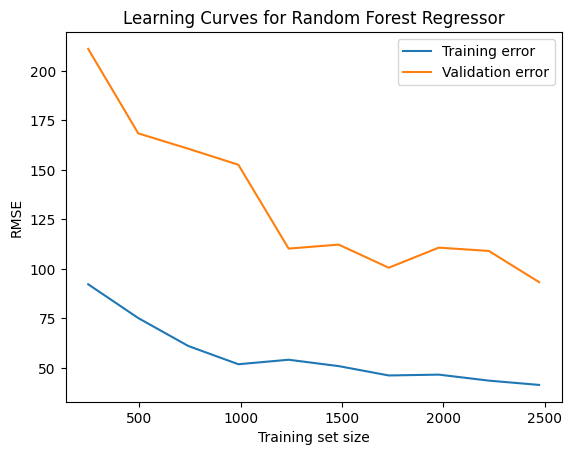

In [57]:
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')

plt.ylabel('RMSE')
plt.xlabel('Training set size')
plt.title('Learning Curves for Random Forest Regressor')
plt.legend()
plt.show()

Gradient Boosting

In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# 3. Evaluate the pipeline
scores = cross_val_score(gb_model, X_train, y_train.values.ravel(), cv=5, scoring=rmse_score)
print("RMSE Scores for each fold: ", scores)      
print("Mean RMSE: ", scores.mean())


RMSE Scores for each fold:  [80.85930175 70.24491541 76.38047933 53.65402008 86.15192751]
Mean RMSE:  73.45812881858166


In [59]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=gb_model,
    X=X_train,
    y=y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=42
)

In [60]:
train_scores_mean = train_scores.mean(axis=1)*(-1)
validation_scores_mean = val_scores.mean(axis=1)*(-1)

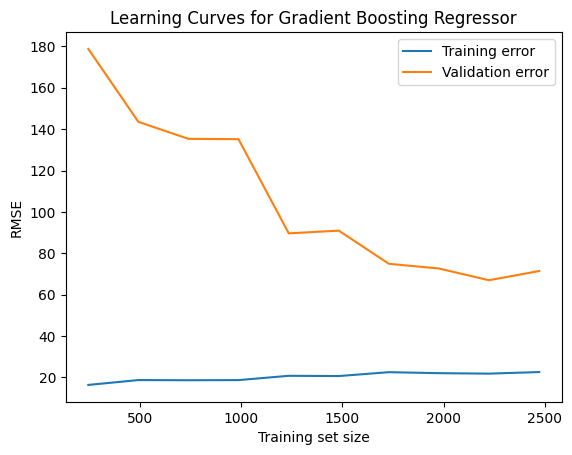

In [61]:
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('RMSE')
plt.xlabel('Training set size')
plt.title('Learning Curves for Gradient Boosting Regressor')
plt.legend()
plt.show()

XGBoost

In [62]:
from xgboost import XGBRegressor  # 1. Import XGBoost Regressor


xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42,learning_rate=0.05))
])

# 3. Evaluate the pipeline
scores = cross_val_score(xgb_pipe, X_train, y_train.values.ravel(), cv=5, scoring=rmse_score)
print("RMSE Scores for each fold: ", scores)      
print("Mean RMSE: ", scores.mean())

RMSE Scores for each fold:  [138.25134277 133.84793091 124.18813324  66.56165314 150.34529114]
Mean RMSE:  122.63887023925781


In [63]:
train_scores_mean = train_scores.mean(axis=1)*(-1)
validation_scores_mean = val_scores.mean(axis=1)*(-1)

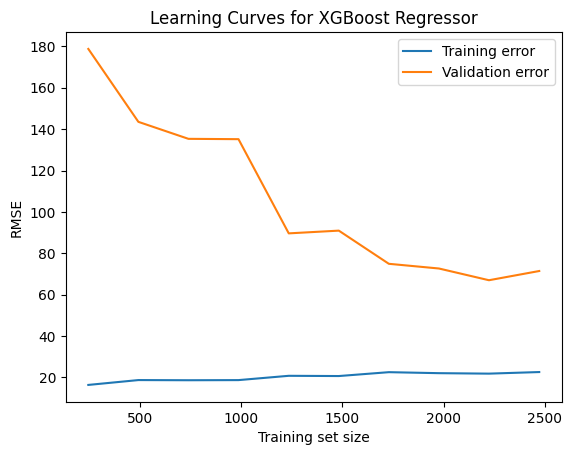

In [64]:
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('RMSE')
plt.xlabel('Training set size')
plt.title('Learning Curves for XGBoost Regressor')
plt.legend()
plt.show()

### HyperParameter Tuning

In [65]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_grid = {
    "model__n_estimators": randint(100, 500),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 8),
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__subsample": uniform(0.7, 0.3)
}

In [ ]:
gb_random = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid,
    n_iter=50, # 50 different combinations
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [67]:
gb_random.fit(X_train, y_train)
print(gb_random.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'model__learning_rate': np.float64(0.06908664112597582), 'model__max_depth': 6, 'model__min_samples_leaf': 3, 'model__min_samples_split': 13, 'model__n_estimators': 459, 'model__subsample': np.float64(0.7824165378970191)}


In [68]:
print("Best CV RMSE:", -gb_random.best_score_)

Best CV RMSE: 56.69283788527324


Evaluate Model

In [69]:
best_gb_model = gb_random.best_estimator_

In [70]:
y_pred = best_gb_model.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 9.918822864476272
RMSE: 38.28123712225266
R²: 0.9928531995135828


In [77]:
import pickle
with open('yield_predict.pkl', 'wb') as file:
    pickle.dump(best_gb_model, file)

### Submission file

In [75]:
print("Test data:", test_data.shape)
print("ID:", len(test_data["ID"]))
print("Predictions:", len(y_pred))

Test data: (1290, 43)
ID: 1290
Predictions: 773


In [ ]:
submission = pd.DataFrame({
    "ID": test_data["ID"],
    "Yield": y_pred
})

In [72]:
# Load files
data_path = ''
train_file = pd.read_csv(data_path + 'Train.csv')
test_file = pd.read_csv(data_path + 'Test.csv')
sample_submission_file = pd.read_csv(data_path + 'SampleSubmission.csv')
var_desc_file = pd.read_csv(data_path + 'VariableDescription.csv')